# Google Colab Stuff

## Mounting Google Drive Folder

In [1]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

## Installing custom packages

In [2]:
#Hide the code cell outputs for cleaner notebook
%%capture 
!pip install keras-tuner
!cp -r /content/drive/Othercomputers/My\ MacBook\ Pro/Documents/Logistic\ Regression/data .

# Loading in packages

In [17]:
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score, auc
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import time
import os
import seaborn as sns
from scipy import interp
# Initialize rng
rng = np.random.default_rng(2022)
n_genes = 100


# Loading in data

In [2]:
data_fr = pd.read_csv("data/aak81Dataset_cpmdat.csv")
# data_fr = pd.read_csv("drive/MyDrive/Secret Notebook/data/aak81Dataset_cpmdat.csv")

# Dropping weird first index column
data_fr.drop('Unnamed: 0', axis = 1, inplace=True)
    
# Make a new column with class = 0 for MGS1 and class = 1 for MGS4
data_fr['class'] = 0
data_fr.loc[data_fr['mgs_level'] == 'MGS4', 'class'] = 1

# data_fr.drop('sample_id', 1, inplace = True)
data_fr.drop('mgs_level', axis = 1, inplace = True)

X = data_fr
y = X['class'].to_numpy()
X.drop('class', axis = 1, inplace = True)

counts = np.bincount(y)
print("number of positive samples in training data: {} ({:.2f}% of total)".format(counts[1], 100 * float(counts[1])/len(y)))

number of positive samples in training data: 61 (36.75% of total)


Data contains 81 columns being the different values of presence of 81 genes in each sample. Sample ID will be recorded for future use.

# Defining extra lists and things to save for plots

In [4]:
# Data to save for later
sens_list = []
spec_list = []
prec_list = []
rec_list = []
f1_list = []
thre_list = []
sampleID_test = []
sampleID_val = []
sampleID_train = []
iter_count = []
n_bootstrap = 100

# Splitting the data

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                        y,
                                                        stratify=y,
                                                        test_size=0.2)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                        y_train_val,
                                                        stratify=y_train_val,
                                                        test_size=0.2)

sampleID_test.append(X_test['sample_id'].to_numpy())
sampleID_val.append(X_val['sample_id'].to_numpy())
sampleID_train.append(X_train['sample_id'].to_numpy())


X_test.drop('sample_id', axis = 1, inplace = True); X_test = X_test.to_numpy()
X_train_val.drop('sample_id', axis = 1, inplace = True); X_train_val = X_train_val.to_numpy()
X_train.drop('sample_id', axis = 1, inplace = True); X_train = X_train.to_numpy()

counts = np.bincount(y_train)
weight_for_0 = 1.0 / counts[0]; weight_for_1 = 1.0 / counts[1]
class_weight = {0:weight_for_0, 1: weight_for_1}

# Defining model

In [6]:
log_regression = LogisticRegression(C = 1, penalty = "l2", tol = 0.0001, class_weight = class_weight, verbose = 0, max_iter = 1000, random_state = None)

log_regression.fit(X_train, y_train)
y_pred = log_regression.predict_proba(X_test)

# Model Performance

Threshold: 0.2233309290475243
Best Sensitivity: 0.9166666666666666
Best Specificity: 0.40909090909090917
Best Precision: 0.55
Best Recall: 0.9166666666666666
Best F1: 0.6874999999999999
AUC: 0.7803030303030303


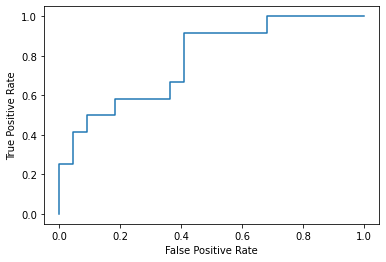

In [8]:
# Printing performance numbers
fpr, tpr, thresholds = sk.metrics.roc_curve(y_test, y_pred[:,1])
youdenJ = tpr - fpr
ix = np.argmax(youdenJ)
best_thresh = thresholds[ix]; print("Threshold:", best_thresh)
best_fpr = fpr[ix]; best_spec = 1 - best_fpr
best_tpr = tpr[ix]; best_sens = best_tpr
print("Best Sensitivity:", best_sens)
print("Best Specificity:", 1 - best_spec)
precision, recall, thresholds = sk.metrics.precision_recall_curve(y_test, y_pred[:,1])
f1score = (2 * precision * recall) / (precision + recall)
ix = np.argmax(f1score)
best_precision = precision[ix]; print("Best Precision:", best_precision)
best_recall = recall[ix]; print("Best Recall:", best_recall)
best_f1 = f1score[ix]; print("Best F1:", best_f1)
print("AUC:", sk.metrics.roc_auc_score(y_test, y_pred[:,1]))

# Plotting
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

Here we can see that this model's performance is not so great. Next, we would have to tune the model.

# Tuning model

## Loading prerequisite packages and variables

In [9]:
import keras_tuner as kt
hp = kt.HyperParameters()

## Defining model function

In [10]:
def build_model(hp):
  model = LogisticRegression(C = hp.Float("C", min_value = 1.0, max_value = 100.0, step = 0.001),
                             penalty = hp.Choice("penalty", values = ['l2']), #'none', 'l2', 'l1', 'elasticnet'
                             tol = hp.Choice("tolerance", values = [0.0001, 0.001, 0.01, 0.1]),
                             solver = hp.Choice("solver", values = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),
                             class_weight = class_weight,
                             verbose = 0,
                             max_iter = 1000,
                             random_state = None)
  return model
  
tuner_logreg = kt.tuners.SklearnTuner(
oracle = kt.oracles.BayesianOptimizationOracle(
    objective = kt.Objective('score', 'max'),
    max_trials = 100
),
hypermodel = build_model,
scoring = sk.metrics.make_scorer(sk.metrics.roc_auc_score),
directory = '.',
overwrite = True,
cv = sk.model_selection.StratifiedKFold(5)
)

tuner_logreg.search(
    X_train_val, y_train_val
)

Trial 100 Complete [00h 00m 00s]
score: 0.7316830065359478

Best score So Far: 0.741454248366013
Total elapsed time: 00h 01m 01s
INFO:tensorflow:Oracle triggered exit


In [11]:
best_param = tuner_logreg.get_best_hyperparameters(1)[0].values
print(best_param)

{'C': 4.277999999999639, 'penalty': 'l2', 'tolerance': 0.01, 'solver': 'newton-cg'}


## Fitting model with the optimized parameters

In [12]:
log_regression = LogisticRegression(
    C = best_param['C'],
    penalty = best_param['penalty'], #'none', 'l2', 'l1', 'elasticnet'
    tol = best_param['tolerance'],
    solver = best_param['solver'],
    class_weight = class_weight,
    verbose = 0,
    max_iter = 1000,
    random_state = None
)

log_regression.fit(X_train_val, y_train_val)

y_pred = log_regression.predict_proba(X_test)


## Model Performance

Threshold: 0.1293411740203334
Best Sensitivity: 0.9166666666666666
Best Specificity: 0.40909090909090917
Best Precision: 0.55
Best Recall: 0.9166666666666666
Best F1: 0.6874999999999999
AUC: 0.7765151515151515


<function matplotlib.pyplot.show(close=None, block=None)>

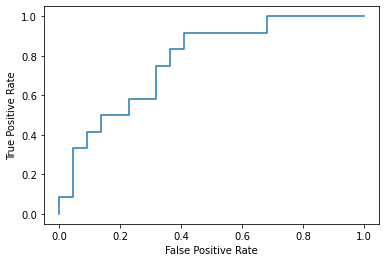

In [13]:
# Printing performance numbers
fpr, tpr, thresholds = sk.metrics.roc_curve(y_test, y_pred[:,1])
youdenJ = tpr - fpr
ix = np.argmax(youdenJ)
best_thresh = thresholds[ix]; print("Threshold:", best_thresh)
best_fpr = fpr[ix]; best_spec = 1 - best_fpr
best_tpr = tpr[ix]; best_sens = best_tpr
print("Best Sensitivity:", best_sens)
print("Best Specificity:", 1 - best_spec)
precision, recall, thresholds = sk.metrics.precision_recall_curve(y_test, y_pred[:,1])
f1score = (2 * precision * recall) / (precision + recall)
ix = np.argmax(f1score)
best_precision = precision[ix]; print("Best Precision:", best_precision)
best_recall = recall[ix]; print("Best Recall:", best_recall)
best_f1 = f1score[ix]; print("Best F1:", best_f1)
print("AUC:", sk.metrics.roc_auc_score(y_test, y_pred[:,1]))

# Plotting
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show

# Running the model 100 times

In [14]:
def build_model(hp):
  model = LogisticRegression(C = hp.Float("C", min_value = 1.0, max_value = 100.0, step = 0.001),
                             penalty = hp.Choice("penalty", values = ['l2']), #'none', 'l2', 'l1', 'elasticnet'
                             tol = hp.Choice("tolerance", values = [0.0001, 0.001, 0.01, 0.1]),
                             solver = hp.Choice("solver", values = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),
                             class_weight = class_weight,
                             verbose = 0,
                             max_iter = 1000,
                             random_state = None)
  return model

# Create lists to save data for later
sens_list = []
spec_list = []
prec_list = []
rec_list = []
f1_list = []
accu_list = []
auc_list = []
param_list = []
sampleID_train = []
sampleID_test = []

# Build an FPR grid to generate TPR on a grid
tprs = []
mean_fpr = np.linspace(0, 1, 100)

startTime = time.perf_counter()
for i in range(100):
    print('Iteration ', i+1)
    # Splitting data every loop
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2)
    # Saving the sample ID used for each iteration
    sampleID_test.append(X_test['sample_id'].to_numpy())
    sampleID_train.append(X_test['sample_id'].to_numpy())
    # Dropping sample id column after saving and convert to np array
    X_test.drop('sample_id', axis = 1, inplace = True); X_test = X_test.to_numpy()
    X_train.drop('sample_id', axis = 1, inplace = True); X_train = X_train.to_numpy()
    #calculating class weight for class balancing
    counts = np.bincount(y_train)
    weight_for_0 = 1.0 / counts[0]
    weight_for_1 = 1.0 / counts[1]
    class_weight = {0:weight_for_0, 1:weight_for_1}
    #Defining optimizer
    tuner_logreg = kt.tuners.SklearnTuner(
        oracle = kt.oracles.BayesianOptimizationOracle(
            objective = kt.Objective('score', 'max'),
            max_trials = 100
        ),
        hypermodel = build_model,
        scoring = sk.metrics.make_scorer(sk.metrics.roc_auc_score),
        directory = '.',
        overwrite = True,
        cv = sk.model_selection.StratifiedKFold(5)
    )
    # Run the Optimizer
    tuner_logreg.search(X_train_val, y_train_val)
    # Extract the best parameters
    best_param = tuner_logreg.get_best_hyperparameters(1)[0].values
    log_regression = LogisticRegression(
        C = best_param['C'],
        penalty = best_param['penalty'], #'none', 'l2', 'l1', 'elasticnet'
        tol = best_param['tolerance'],
        solver = best_param['solver'],
        class_weight = class_weight,
        verbose = 0,
        max_iter = 1000,
        random_state = None
    )
    log_regression.fit(X_train_val, y_train_val)
    y_pred = log_regression.predict_proba(X_test)
    fpr, tpr, thresholds = sk.metrics.roc_curve(y_test, y_pred[:, 1])
    youdenJ = tpr - fpr
    ix = np.argmax(youdenJ)
    best_spec = 1 - fpr[ix]; spec_list.append(best_spec)
    best_sens = tpr[ix]; sens_list.append(best_sens)
    precision, recall, thresholds = sk.metrics.precision_recall_curve(y_test, y_pred[:, 1])
    f1score = (2 * precision * recall) / (precision + recall)
    ix = np.argmax(f1score)
    best_precision = precision[ix]; prec_list.append(best_precision)
    best_recall = recall[ix]; rec_list.append(best_recall)
    best_f1 = f1score[ix]; f1_list.append(best_f1)
    auc = sk.metrics.roc_auc_score(y_test, y_pred[:, 1]); auc_list.append(auc)
    param_list.append(best_param)
    # Interpolation for plotting
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    
    stopTime = time.perf_counter()
    print("Elapsed Time: ", stopTime - startTime, "seconds")




Trial 100 Complete [00h 00m 00s]
score: 0.7316830065359478

Best score So Far: 0.7316830065359478
Total elapsed time: 00h 00m 36s
INFO:tensorflow:Oracle triggered exit
Elapsed Time:  4993.251252584 seconds


In [15]:
# Save the metrics for each iteration
results_list = pd.DataFrame(
    {
        
        'AUC': auc_list,
        'Sensitivity': sens_list,
        'Specificity': spec_list,
        'Precision': prec_list,
        'Recall': rec_list,
        'F1': f1_list
    }
)
results_list.to_csv('results/LogReg_Bayesian_results.csv')
# Save the best parameters of each iteration
param_df = pd.DataFrame.from_dict(param_list, orient = "columns")
param_df.to_csv('results/Logreg_best_param_Bayesian.csv')
# Save the sample ID from each iteration
df_train = pd.DataFrame() 
for i in range(len(sampleID_train)):
    df_train["Iter_" + str(i+1)] = sampleID_train[i]
df_test = pd.DataFrame()
for i in range(len(sampleID_test)):
    df_test['Iter_' + str(i+1)] = sampleID_test[i]

df_train.to_csv('results/sampleID_train.csv', index = False)
df_test.to_csv('results/sampleID_test.csv', index = False)

# Plotting and saving plots

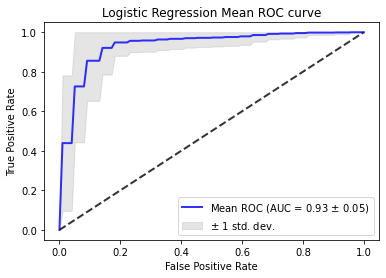

<Figure size 432x288 with 0 Axes>

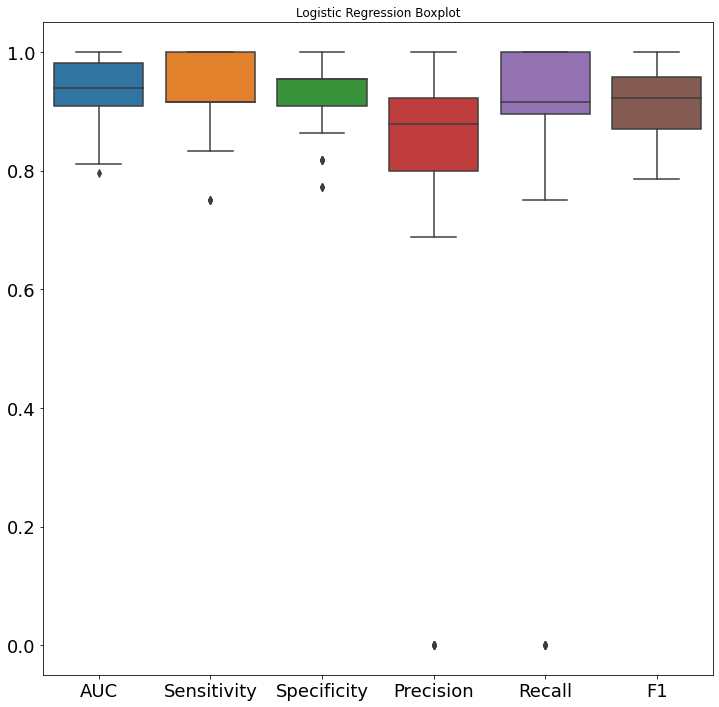

In [18]:
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(auc_list)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Mean ROC curve')
plt.legend(loc="lower right")

plt.savefig('results/{}_Bayesian_ROC.pdf'.format("LogisticRegression"))


#BOXPLOT!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(1,1,1)
sns.boxplot(data=results_list, ax=ax)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.title('Logistic Regression Boxplot')
plt.savefig('results/{}_Bayesian_boxplot.pdf'.format("LogisticRegression"))